# sme_contrib.plot

In [2]:
!pip install -q sme_contrib
import sme
import sme_contrib.plot as smeplot
from matplotlib import pyplot as plt
import pyvista as pv
from pyvista import examples
import numpy as np
import tempfile
from IPython.display import HTML
from IPython.display import Video


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
pv.set_jupyter_backend('static')

## Load and simulate example model

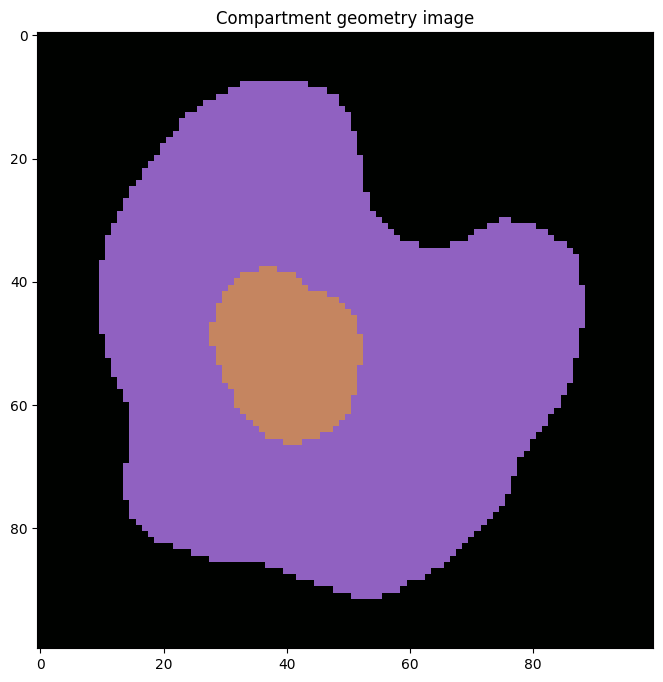

In [3]:
model = sme.open_example_model()
fig = plt.figure(figsize=(16, 8))
plt.imshow(model.compartment_image[0, :])
plt.title("Compartment geometry image")
plt.show()
results = model.simulate(100, 1)
species = ["B_out", "B_cell"]

## Plot resulting species concentration

### Use default colormap

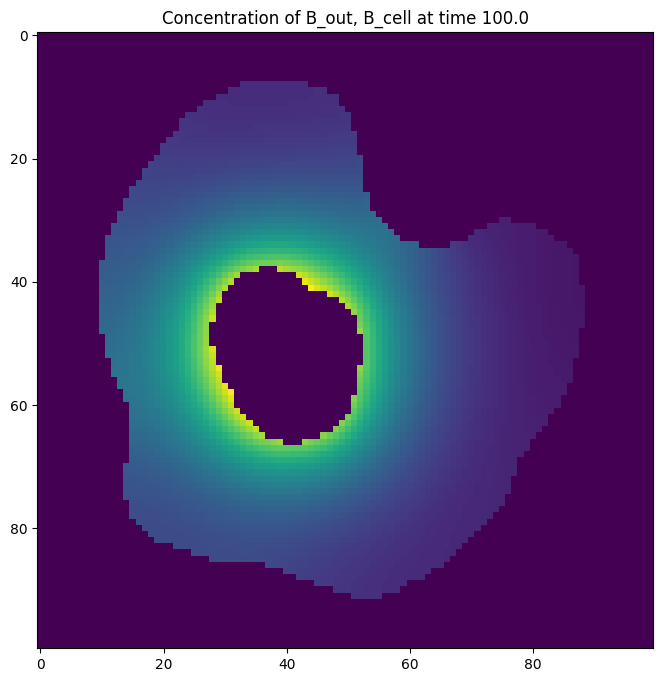

In [4]:
fig = plt.figure(figsize=(16, 8))
smeplot.concentration_heatmap(results[-1], species)
plt.show()

### Use a built-in matplotlib colormap

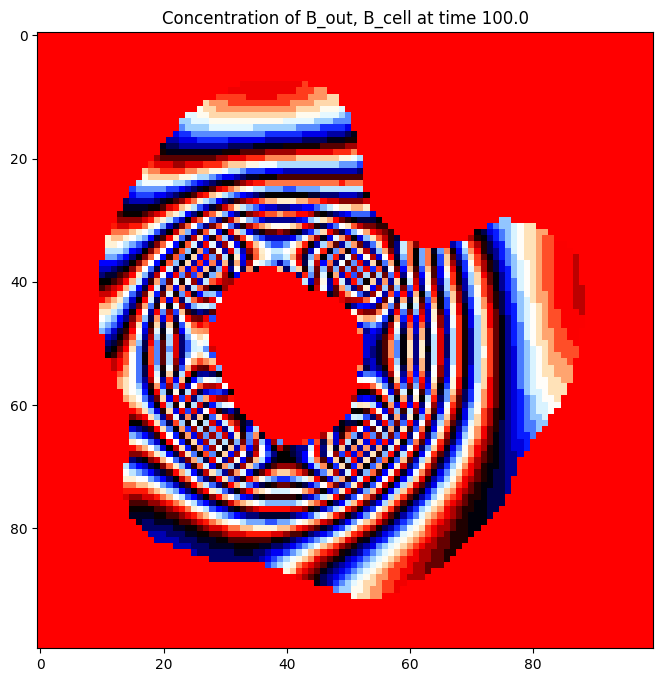

In [5]:
fig = plt.figure(figsize=(16, 8))
smeplot.concentration_heatmap(results[-1], species, cmap="flag")
plt.show()

### Create your own colormap

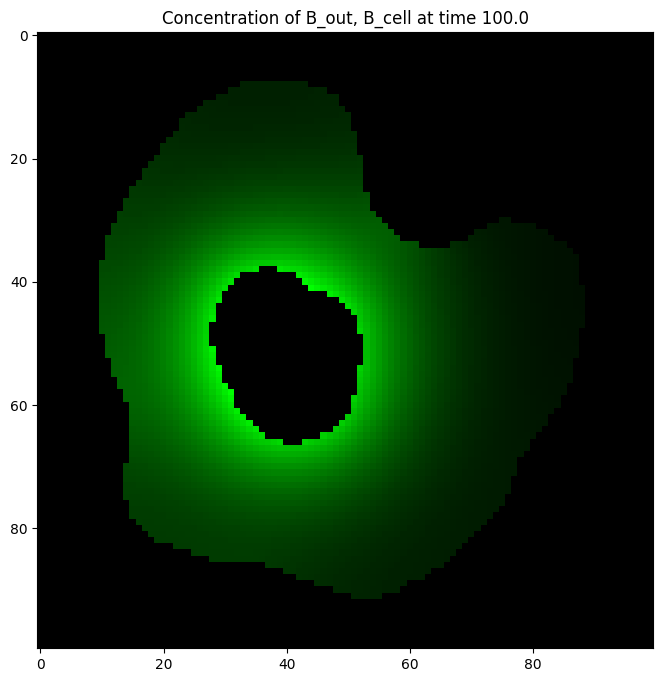

In [6]:
# make a black -> green colormap using sme_contrib.plot.colormap:
cmap = smeplot.colormap("#00ff00")
fig = plt.figure(figsize=(16, 8))
smeplot.concentration_heatmap(results[-1], species, cmap=cmap)
plt.show()

### Display on existing axes with colorbar

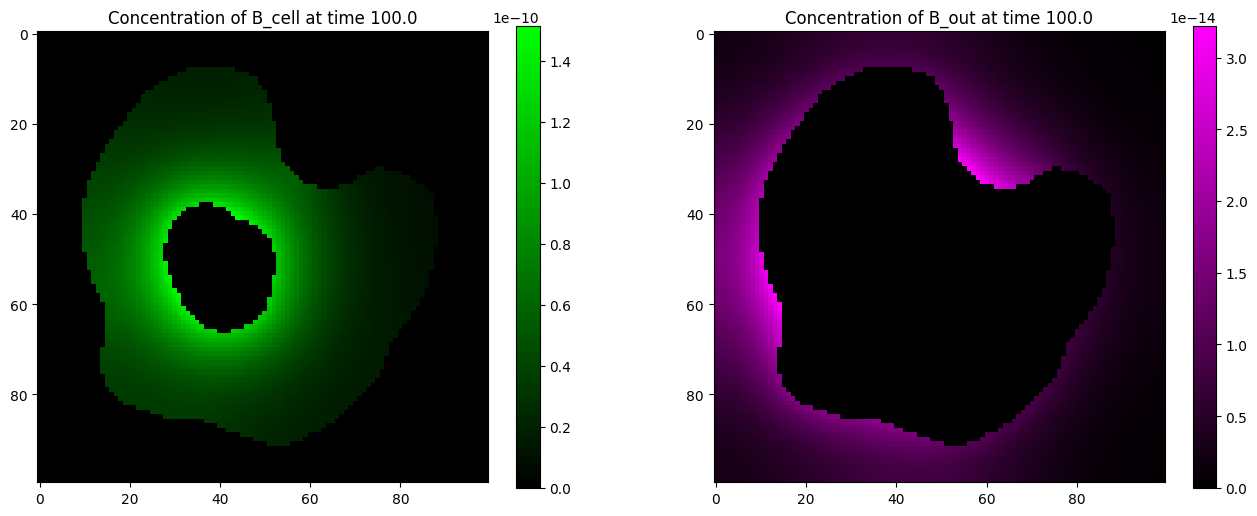

In [7]:
fig, (ax_l, ax_r) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
ax_l, im_l = smeplot.concentration_heatmap(
    results[-1], ["B_cell"], cmap=smeplot.colormap("#00ff00"), ax=ax_l
)
ax_r, im_r = smeplot.concentration_heatmap(
    results[-1], ["B_out"], cmap=smeplot.colormap("#ff00ff"), ax=ax_r
)
fig.colorbar(im_l, ax=ax_l)
fig.colorbar(im_r, ax=ax_r)
plt.show()

## Plot animation of species concentration

In [8]:
anim = smeplot.concentration_heatmap_animation(results, ["B_cell"], figsize=(8, 6))

### Display as html5 video

In [9]:
HTML(anim.to_html5_video())

### Display as javascript widget

In [10]:
HTML(anim.to_jshtml())

# Plot concentrations on 3D grid

The API for 3D plotting has two layers: 
- the low-level function provide a high degree of customisability, but need more code to get them to work:
    - `facet_grid_3D`: two low-level functions that map a dictionary of name->plotfunctions over a dictionary name->data, where both have to have the same keys. 
  For each key in the data dictionary, a single plot pane will be created.  
    - `facet_grid_animate_3D` is an animated version of this function that creates an .mp4 file for and receives a dictionary of name->data for each frame of the animation over which the dictionary containing the plot functions is then mapped in each frame. 
- `concentrations3D` and `concentrationsAnimate3D`: These high-level API directly uses `sme.SimulationResult` objects as data input, but only plots concentrations by default. These are wrappers around the low-level functions that provide default plotting functions for each pane and handle the data preparation for each pane automatically.

In [11]:
model_file = "./model.xml"
model = sme.open_sbml_file(model_file)
results = model.simulate(500, 10)

species = list(results[0].species_concentration.keys())
species

['A_cell', 'A_nucl']

In [12]:
def exampledata():
    armadillo = examples.download_armadillo()
    bloodvessel = examples.download_blood_vessels()
    brain = examples.download_brain()

    return {
        "armadillo": armadillo,
        "bloodvessel": bloodvessel,
        "brain": brain,
    }


datasets = exampledata()
tempdir = tempfile.TemporaryDirectory()

## Low level functions

We are plotting some example functions here to show the functionality of the `facetGrid` functions.
We first define the functions that are applied to each pane in the grid:

In [13]:
def plot_bloodvessel(label, data, plotter, panel, **kwargs):
    plotter.subplot(*panel)
    plotter.add_mesh(data)


def plot_brain(label, data, plotter, panel, **kwargs):
    plotter.subplot(*panel)
    plotter.add_volume(
        data,
        cmap="viridis",
        opacity="sigmoid",  # Common opacity mapping for volume rendering
        shade=True,
        ambient=0.3,
        diffuse=0.6,
        specular=0.5,
    )


def plot_armadillo(label, data, plotter, panel, **kwargs):
    plotter.subplot(*panel)
    plotter.add_mesh(data)

Then we put the it all together in the call to `facet_grid_3D`:

In [14]:
facetgrid = smeplot.facet_grid_3D(
    data={
        "armadillo": datasets["armadillo"],
        "bloodvessel": datasets["bloodvessel"],
        "brain": datasets["brain"],
    },
    plotfuncs={
        "armadillo": plot_armadillo,
        "bloodvessel": plot_bloodvessel,
        "brain": plot_brain,
    },

    linked_views=False
)

In [15]:
facetgrid.show()

Widget(value='<iframe src="http://localhost:49863/index.html?ui=P_0x131b80e80_0&reconnect=auto" class="pyvista…

Making an animation functions in much the same way, but we use a list of data dictionaries now, one for each frame.

We define a general plotting function that is used for each pane in each frame here. these can be different too, like shown above: 

In [16]:
def plotfunc(
    label,
    data,
    plotter,
    panel,
    show_cmap,
    cmap,
    **kwargs,
):
    # create a pyvista grid
    plotter.subplot(*panel)
    plotter.title = label
    plotter.add_mesh(
        data,
        scalars=data,
        label=label,
        cmap=cmap,
        show_scalar_bar=show_cmap,
        **kwargs,
    )

Then use it in the call to `facet_grid_animate_3D` call. Note that we pass a list of data dictionaries now, while the `plotfuncs` dict stays a dictionary. You can use the plot function to customize lighting, perspective and more. See [the pyvista documentation for more information](https://docs.pyvista.org/api/plotting/_autosummary/pyvista.plotter.add_mesh).

In [17]:
vidpath = smeplot.facet_grid_animate_3D(
    "testvid.mp4",
    data=[
        {species[i]: res.species_concentration[species[i]] for i in range(len(species))}
        for res in results
    ],
    plotfuncs={species[i]: plotfunc for i in range(len(species))},
    cmap="tab10",
    portrait=True,
    linked_views=True,
)
Video(vidpath, embed=True, width=800, height=600)

## High-level functions

The high level functions wrap the low-level functions such that we don´t have to specify the plotting functions ourselves.

In [18]:
facetgrid = smeplot.concentrations3D(
    simulation_result=results[10],
    species=["A_nucl"],
    cmap="tab10",
    show_cmap=True,
)

facetgrid.show()

Widget(value='<iframe src="http://localhost:49863/index.html?ui=P_0x13badf9d0_1&reconnect=auto" class="pyvista…

# Animate concentations on  a 3D grid

In [20]:
vidpath = smeplot.concentrationsAnimate3D(
    filename="test.mp4",
    simulation_results=results,
    species=["A_nucl"],
    cmap="tab10",
)

Video(vidpath, embed=True, width=800, height=600)